## Trabalho Final de Modelos de Regressão

#### Aluno : Renan Lemes Leepkaln

#### Dados utilizados **Medical Cost Personal Datasets**

#### Descrição dos dados 
* age - Idade
* sex - sexo 
* bmi - indice de massa corporal
* children - quantidade de filhos
* smoker - se a pessoa é fumante 
* region - região 
* charges - custos médico associado a cada individuo

#### Situalizando o problema
Temos dados relacionado a um hospital e queremos prever os gastos para gerar um bom controle e uma administração melhor com base nas colunas do dataframe.


#### Modelo utilizado
##### definida por :
$$
    g(\mu_i) = \beta_0 + \beta_1 x_{ji} + \beta_2 x_{i2} + ... + \beta_p x_{ip}
$$
* $g(\cdot)$ é a função ligação
    * $g(\mu) = \mu_i^{-1}$ função inversa (ligação canonica)
    * $g(\mu) = log(\mu_i)$ função logaritimica (efeitos multiplicativos)
    * $g(\mu) = \mu_i$ função identidade (efeitos aditivos)
* $\mu$ é a média da distribuição de gammma
* $\beta_0, \beta_1 ..., \beta_p$ são coeficientes do modelo 
* $x_1, x_2, ..., x_p$ são os preditores do modelo

In [132]:
## libs para tratar os dados
import pandas as pd 
import numpy as np

## libs para plotar graficos
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [133]:
## Libs para rodar os modelos
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [26]:
df = pd.read_csv("insurance.csv")

In [27]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


#### Processamento dos dados 

In [28]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [29]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Notei que temos smoker region e sex para transformar em dummy

In [31]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [32]:
df_dummy = pd.get_dummies(df, columns=["sex", "smoker", "region"])

df_dummy.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [33]:
df_dummy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   bmi               1338 non-null   float64
 2   children          1338 non-null   int64  
 3   charges           1338 non-null   float64
 4   sex_female        1338 non-null   bool   
 5   sex_male          1338 non-null   bool   
 6   smoker_no         1338 non-null   bool   
 7   smoker_yes        1338 non-null   bool   
 8   region_northeast  1338 non-null   bool   
 9   region_northwest  1338 non-null   bool   
 10  region_southeast  1338 non-null   bool   
 11  region_southwest  1338 non-null   bool   
dtypes: bool(8), float64(2), int64(2)
memory usage: 52.4 KB


Como visto antes não necessitamos fazer nenhuma alteração nos dados sem valores faltantes e sem valores vazios.

#### Análise descritiva 

In [54]:
df_dummy.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [48]:
plt.style.use("default")

In [49]:
size = [len(df["sex"][df.sex == "male"]), len(df["sex"][df.sex == "female"])]
labels = ['male', 'female']


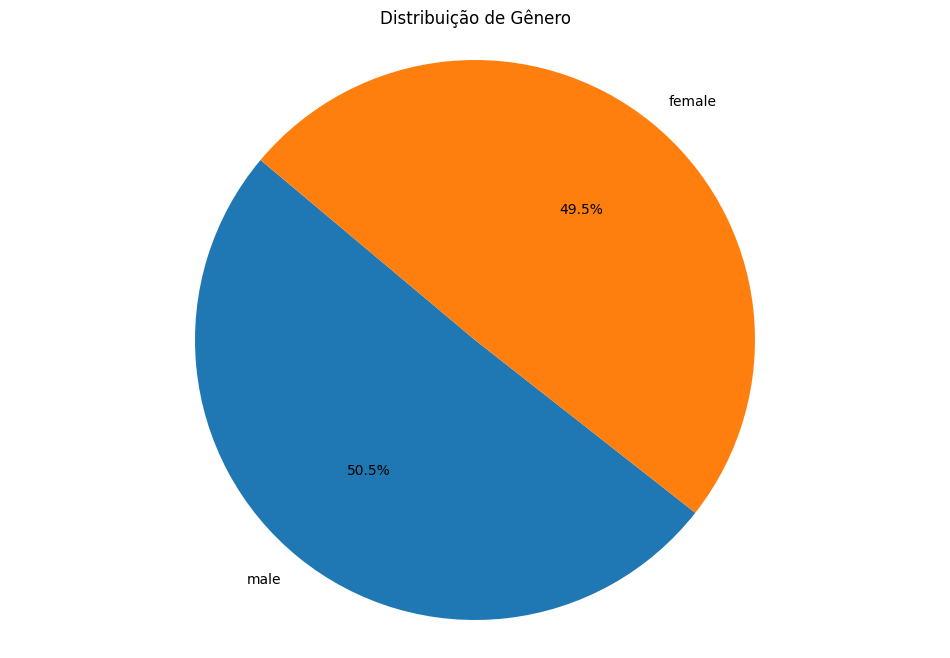

In [50]:
# Criar o gráfico de pizza
plt.figure(figsize=(12, 8))  # Define o tamanho da figura (opcional)
plt.pie(
    size, labels=labels, autopct="%1.1f%%", startangle=140
)  # Cria o gráfico de pizza com rótulos
plt.title("Distribuição de Gênero")  # Define o título do gráfico
plt.axis("equal")  # Faz com que o gráfico de pizza seja circular
plt.show()  # Mostra o gráfico

Aqui deu para notar que nossa base de dados está bem distribuida. Vamos fazer o mesmo para fumantes e não fumantes.

In [51]:
labels = ['fumantes', 'não fumantes']
size = [sum(df.smoker == 'yes'), sum(df.smoker == 'no')]


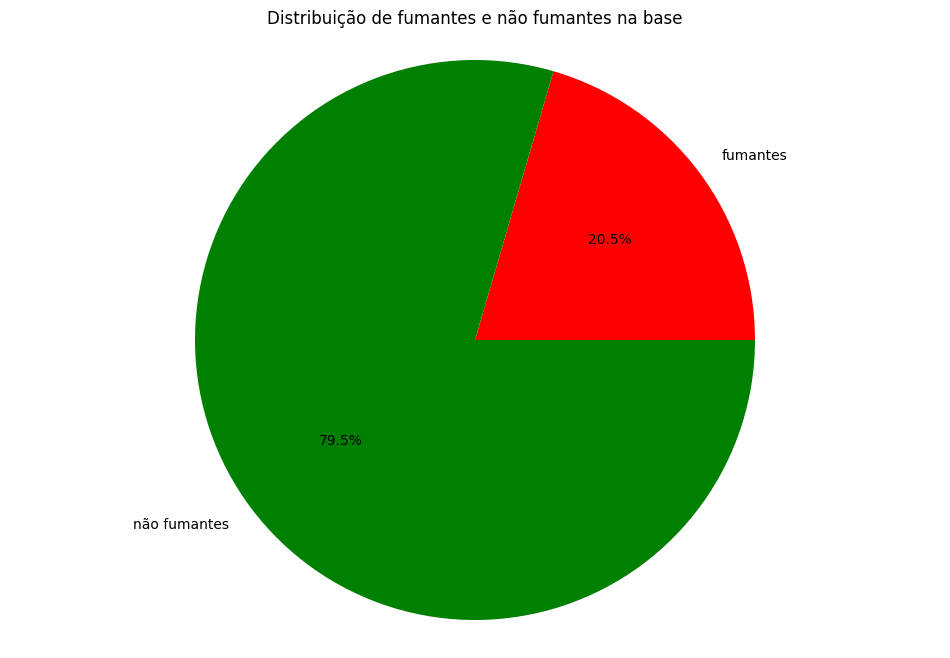

In [53]:

plt.figure(figsize=(12, 8))  
plt.pie(
    size, labels=labels, autopct="%1.1f%%", colors=['red', 'green']
) 
plt.title("Distribuição de fumantes e não fumantes na base")
plt.axis("equal")
plt.show()

Aqui notamos uma grande diferença na distribuição em não fumantes. 

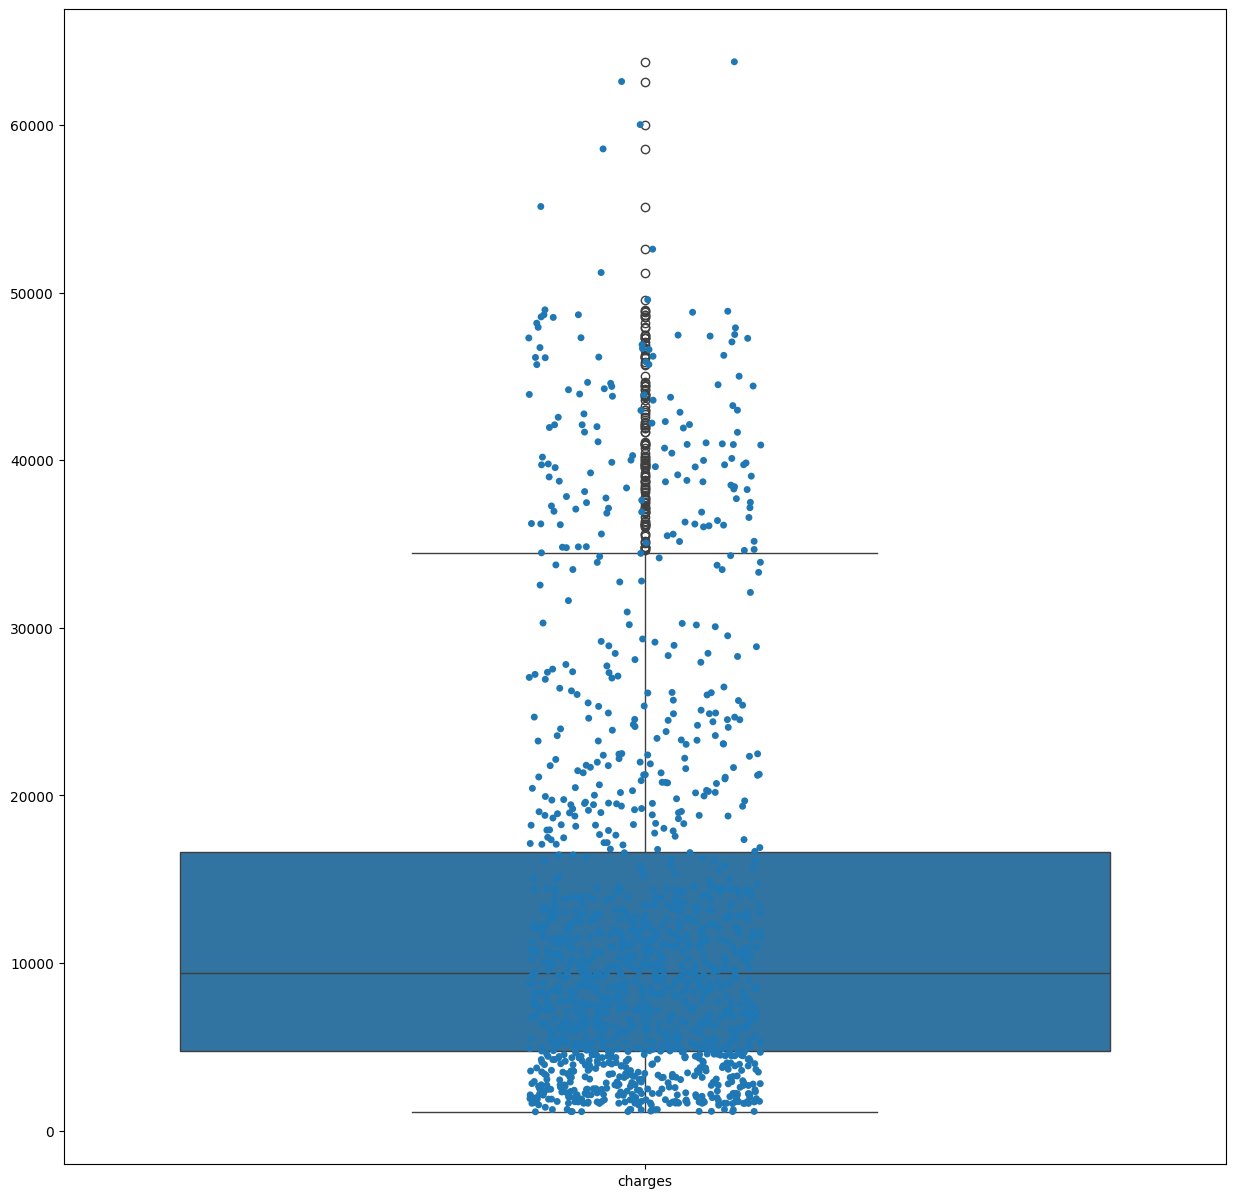

In [59]:
## Grafico box plot para análisar os outliers
fig, ax = plt.subplots(figsize=(15, 15))

sns.boxplot(data=df_dummy[["charges"]])
sns.stripplot(data=df_dummy[["charges"]])

plt.show()

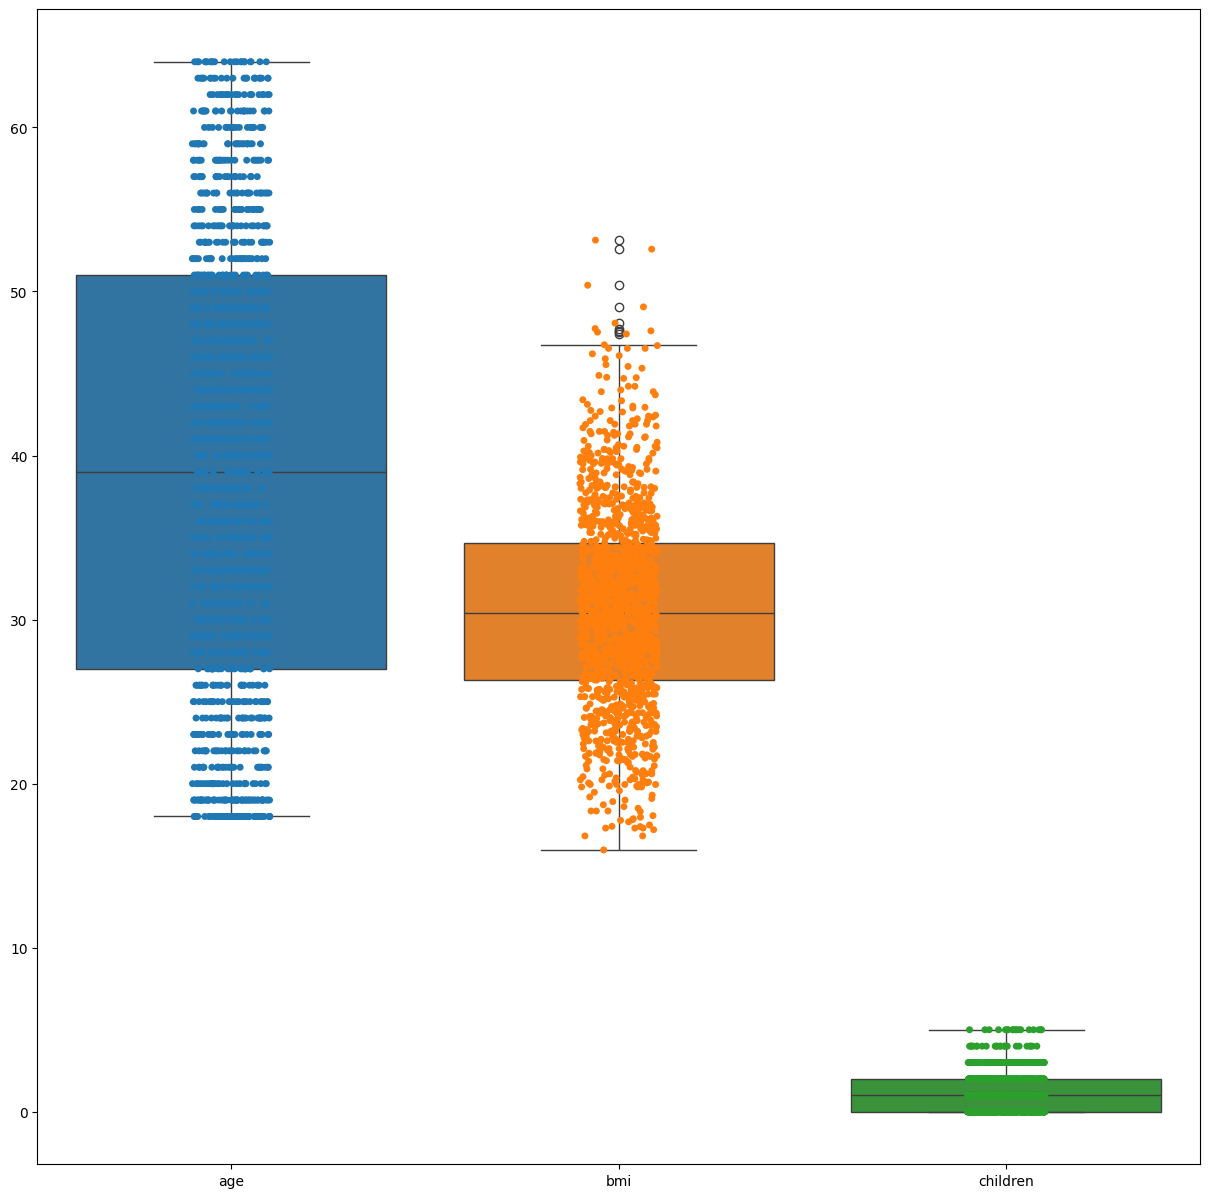

In [58]:
## Grafico box plot para análisar os outliers
fig, ax = plt.subplots(figsize=(15, 15))

sns.boxplot(data=df_dummy[["age", "bmi", "children"]])
sns.stripplot(data=df_dummy[["age", "bmi", "children"]])

plt.show()

Aparentemente temos muito mais outliers nas variavel charges do que na bmi 

In [92]:
# Calcular estatísticas descritivas
desc = df_dummy.describe()

# Alinhar os dataframes
desc, df_dummy = desc.align(df_dummy, axis=1)

Q1 = desc.loc["25%"] ## pegar o quartil de 25% o inferior
Q3 = desc.loc["75%"] ## pegar o quartil de 75% o superior
IQR = Q3 - Q1

limit_sup = Q3 + 1.5 * IQR
limit_inf = Q1 - 1.5 * IQR

## criar um dataframe com os varoles todos acima do limite inferior e limite superior
out_liers = df_dummy[(df_dummy < limit_inf) | (df_dummy > limit_sup)]

In [99]:
out_liers.head()

,age,bmi,charges,children,region_northeast,region_northwest,region_southeast,region_southwest,sex_female,sex_male,smoker_no,smoker_yes
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [137]:
df = df_dummy[df_dummy != out_liers] ## aqui pegamos e fazemos uma mascara para transformar os valores de outliers em NaN

In [138]:
## Ai aqui vou alterar os valores de NaN para a mediana

mediana = df.bmi.median()
df.bmi.fillna(mediana, inplace=True)

In [139]:
mediana = df.charges.median()
df.charges.fillna(mediana, inplace=True)

In [140]:
df.isna().sum()

age                 0
bmi                 0
charges             0
children            0
region_northeast    0
region_northwest    0
region_southeast    0
region_southwest    0
sex_female          0
sex_male            0
smoker_no           0
smoker_yes          0
dtype: int64

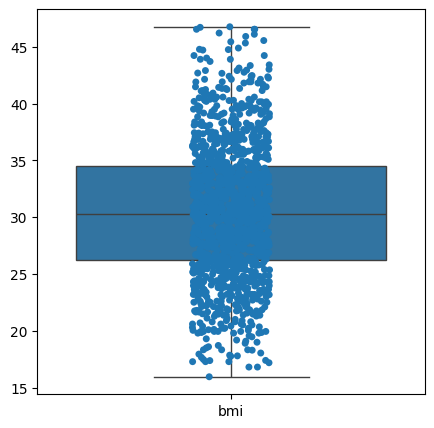

In [117]:
## Grafico box plot para análisar os outliers
fig, ax = plt.subplots(figsize=(5, 5))

sns.boxplot(data=df[["bmi"]])
sns.stripplot(data=df[["bmi"]])

plt.show()

In [124]:
df.head()

,age,bmi,charges,children,region_northeast,region_northwest,region_southeast,region_southwest,sex_female,sex_male,smoker_no,smoker_yes
0,19,27.900,16884.92400,0,False,False,False,True,True,False,False,True
1,18,33.770,1725.55230,1,False,False,True,False,False,True,True,False
2,28,33.000,4449.46200,3,False,False,True,False,False,True,True,False
3,33,22.705,21984.47061,0,False,True,False,False,False,True,True,False
4,32,28.880,3866.85520,0,False,True,False,False,False,True,True,False


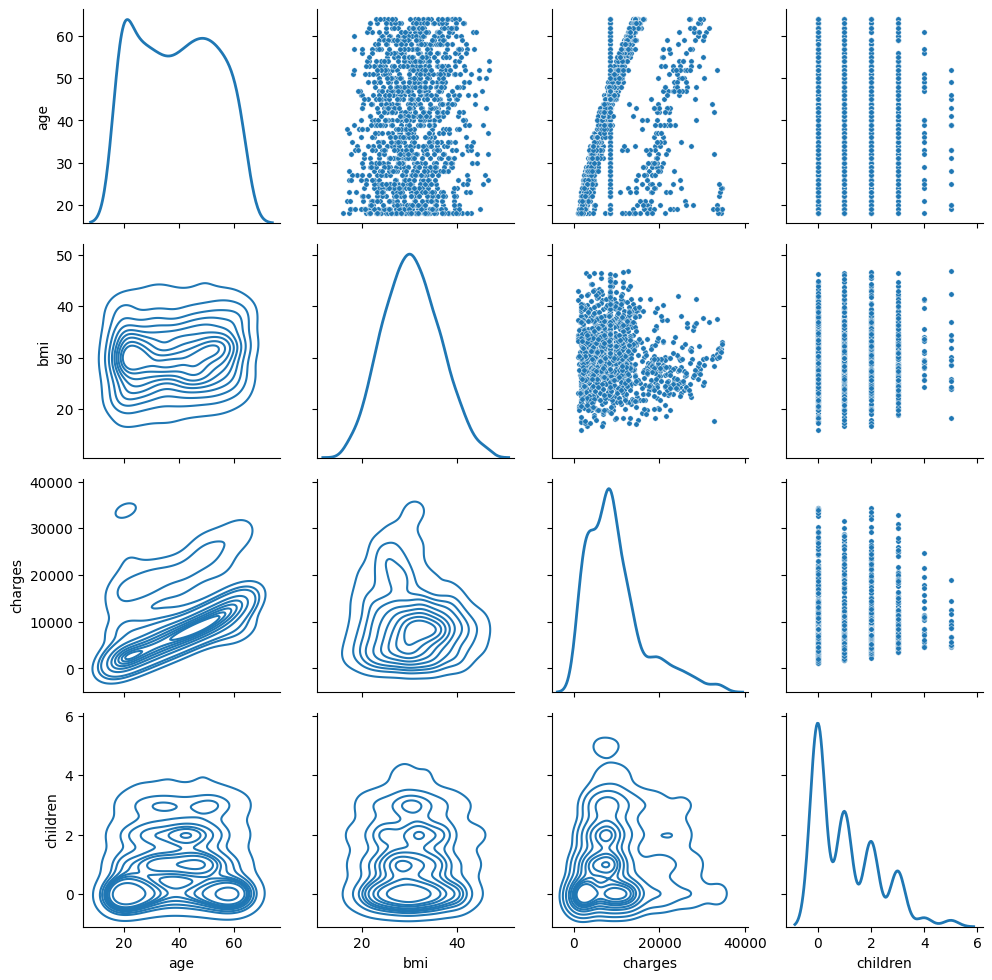

In [126]:
graph = sns.PairGrid(df[['age', 'bmi', 'charges', 'children']], diag_sharey=False)
graph.map_upper(sns.scatterplot, s=15)
graph.map_lower(sns.kdeplot)
graph.map_diag(sns.kdeplot, lw=2)

Conseguimos notar que quanto maior a idade maior o gasto com medicamentos isso esta relacionado ao que aparenta ao o grafico de exponencial

In [141]:
scaler = StandardScaler()
df_scale = scaler.fit_transform(df)

In [145]:
m_corr = df.corr()
m_cov = np.cov(df_scale, rowvar=False)

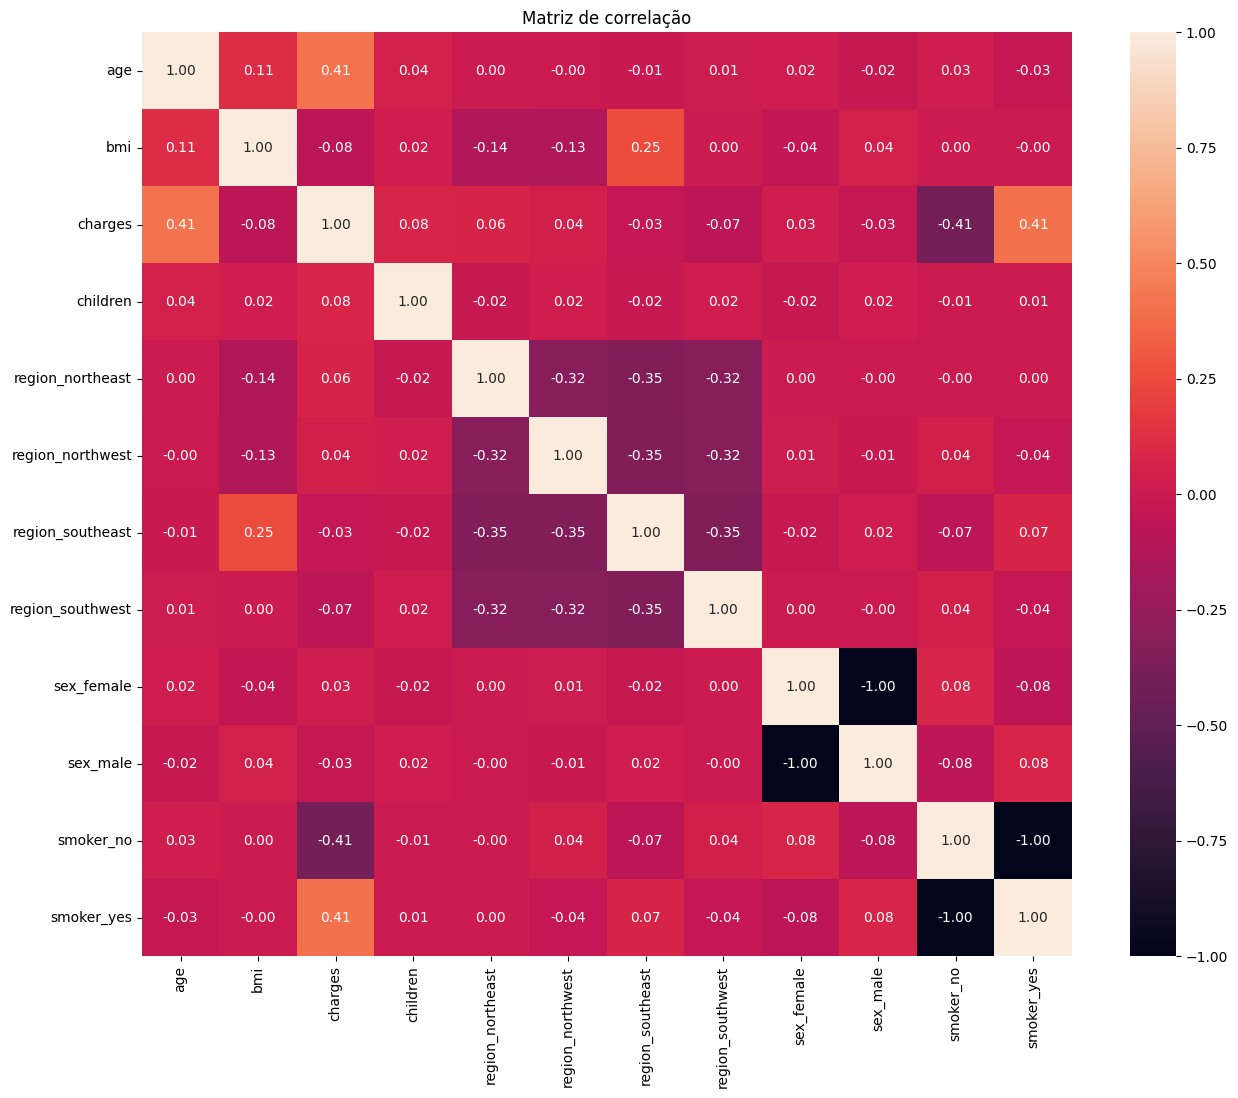

In [146]:
plt.figure(figsize=(15, 12))
plt.title("Matriz de correlação")
sns.heatmap(m_corr, annot=True, fmt=".2f")
plt.show()

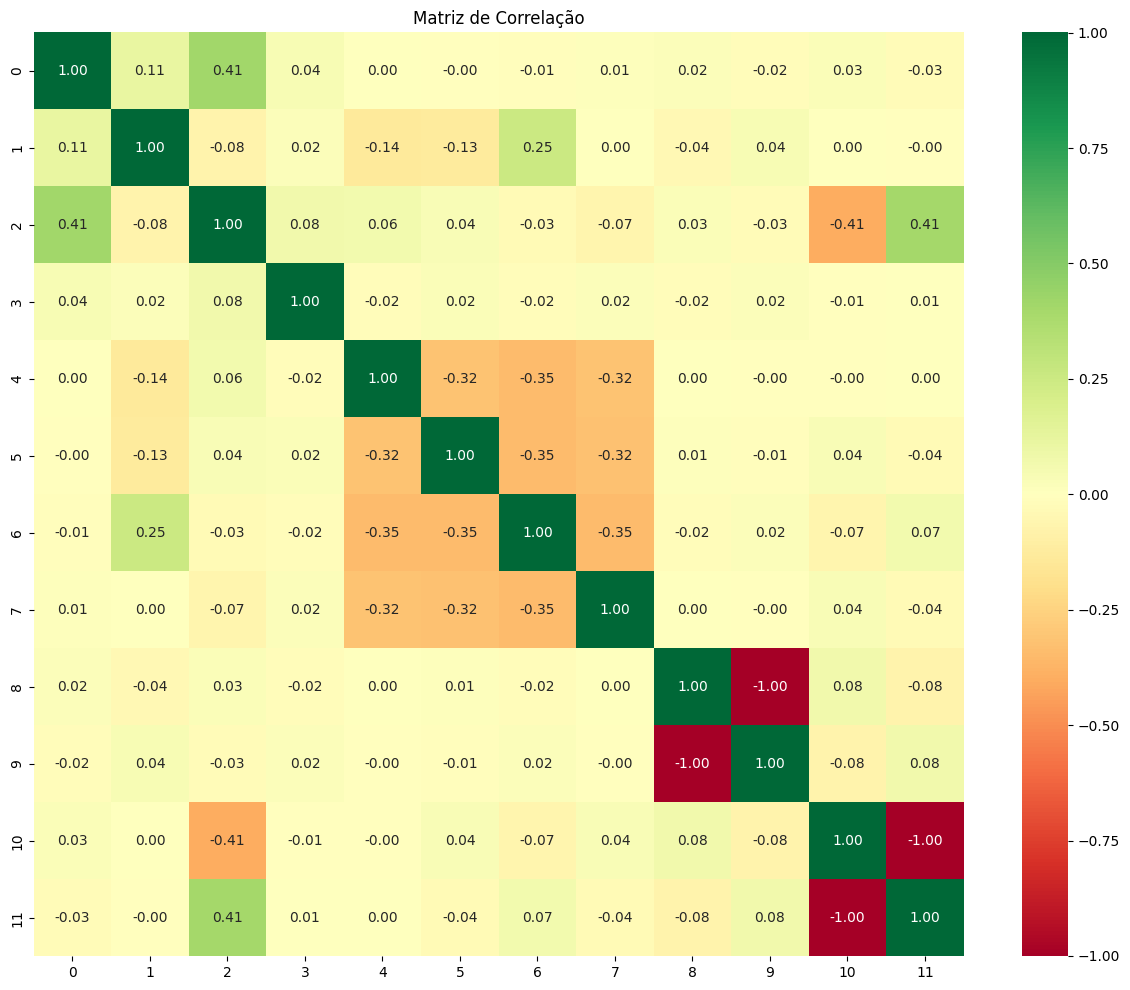

In [147]:
plt.figure(figsize=(15, 12))
sns.heatmap(m_cov, annot=True, cmap="RdYlGn", fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

O que conseguimos notar da covariancia e da correlação e que elas são correlatas com fumantes e não fumantes.

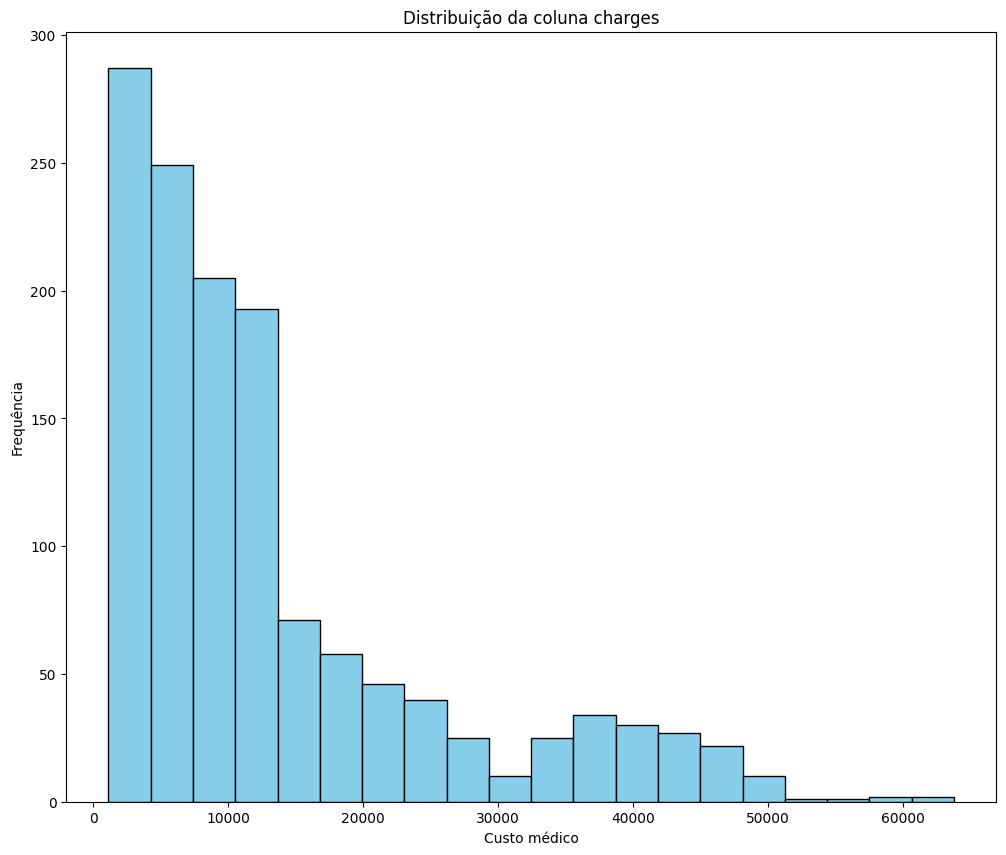

In [149]:
##
plt.figure(figsize=(12, 10))
plt.hist(df_dummy["charges"], bins=20, density=False, color="skyblue", edgecolor="black")
# Adiciona título e rótulos dos eixos
plt.title("Distribuição da coluna charges")
plt.xlabel("Custo médico")
plt.ylabel("Frequência")

# Exibe o histograma
plt.show()

Realmente a distribuição da nossa variavel y segue a gamm, assim como mostra a img abaixo.


<center>
    <img src="https://www.researchgate.net/profile/Jose-Siqueira-18/publication/326522285/figure/fig1/AS:650591076372480@1532124408587/Figura-21-Distribuicao-gama-invertida-com-2-7-ao-dia-util-e-5.png" width="400">
</center>

Analisando os pressupostos, temos uma distribuição consistente e correlações adequadas, sem valores extremamente altos. Notamos uma relação exponencial entre a idade e o custo médico, o que nos permite aplicar nosso modelo com confiança. Veremos realmente se vai ter uma grande relevância o modelo.